In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import torch
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os
import sys

In [4]:
project_root = os.path.abspath(os.path.join(os.getcwd(), '../..'))
sys.path.append(project_root)

from nn.models.googlenet import create_googlenet
from nn.training.data_loader import get_data_loaders

In [6]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

model = create_googlenet()
val_data, val_loader = get_data_loaders()
model = model.to(device)

/Users/OAA/Desktop/EUPA/nn/notebooks/../data/imagenet/val


In [65]:
# for inputs, labels in val_loader:
#     print(f"Inputs shape: {inputs.shape}, labels shape: {labels.shape}")
#     print(labels)
#     break

In [7]:
data_iter = iter(val_loader)
images, labels = next(data_iter)

image = images[0]
label = labels[0]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(3, 224, 224)


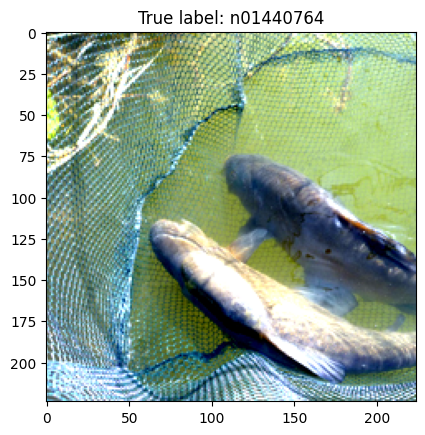

In [8]:
image = image / 2 + 0.5 # unnormalize
image_np = image.numpy()
print(image_np.shape)
image_np = image_np.transpose((1, 2, 0)) # (C, H, W) -> (H, W, C)

plt.imshow(image_np)
plt.title(f"True label: {val_data.classes[label]}")
plt.show()

In [9]:
model.eval()
image = image.to(device)
image = image.unsqueeze(0)

with torch.no_grad():
    outputs = model(image)
    _, predicted = torch.max(outputs, 1) # get the index of the class with the highest probability

predicted = predicted.item()
print(f"Predicted: {val_data.classes[predicted]}")

Predicted: n01695060


In [ ]:
# Load a batch of images
images, labels = next(iter(val_loader))

# Loop through the batch
for i in range(len(images)):
    image = images[i] / 2 + 0.5  # Unnormalize
    print(image.shape)
    image_np = image.numpy().transpose((1, 2, 0))
    
    # Move to device and get prediction
    img = images[i].unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(img)
        _, predicted = torch.max(output, 1)
    
    # Display image and prediction
    plt.imshow(image_np)
    plt.title(f"True Label: {val_data.classes[labels[i]]}, Predicted: {val_data.classes[predicted.item()]}")
    plt.show()

## Overfitting onto a small dataset

In [69]:
criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4) # SGD is common for ImageNet

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.1) # Reduce the learning rate by a factor of 10 every 8 epochs

dataset = val_data

In [76]:
# Create a small dataset and DataLoader
small_dataset = torch.utils.data.Subset(dataset, range(10))
small_loader = DataLoader(small_dataset, batch_size=1, shuffle=True)    

# Train the model on this small dataset and check accuracy
for epoch in range(10):  # Overfit for several epochs
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in small_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        # Calculate accuracy
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        print(f"Loss: {running_loss / total}, Accuracy: {correct / total}")


Image: torch.Size([1, 3, 224, 224]), Label: torch.Size([1])
Loss: 2.682172998902388e-05, Accuracy: 1.0
Image: torch.Size([1, 3, 224, 224]), Label: torch.Size([1])
Loss: 2.6702524337451905e-05, Accuracy: 1.0
Image: torch.Size([1, 3, 224, 224]), Label: torch.Size([1])
Loss: 3.079524200681286e-05, Accuracy: 1.0
Image: torch.Size([1, 3, 224, 224]), Label: torch.Size([1])
Loss: 3.611970714700874e-05, Accuracy: 1.0
Image: torch.Size([1, 3, 224, 224]), Label: torch.Size([1])
Loss: 3.466541202215012e-05, Accuracy: 1.0
Image: torch.Size([1, 3, 224, 224]), Label: torch.Size([1])
Loss: 3.206672742332254e-05, Accuracy: 1.0
Image: torch.Size([1, 3, 224, 224]), Label: torch.Size([1])
Loss: 3.2015647645623956e-05, Accuracy: 1.0
Image: torch.Size([1, 3, 224, 224]), Label: torch.Size([1])
Loss: 3.3407795626771986e-05, Accuracy: 1.0
Image: torch.Size([1, 3, 224, 224]), Label: torch.Size([1])
Loss: 3.2834952031003515e-05, Accuracy: 1.0
Image: torch.Size([1, 3, 224, 224]), Label: torch.Size([1])
Loss: 3.2

In [95]:
# Check the dimensions of the array
print(images.shape)
print(labels.shape)

# Ensure that the index is within the bounds of the array
if len(images) > 0 and len(labels) > 0:
    image = images[0]
    label = labels[0]
    print(f"Image: {image.shape}, Label: {label.shape}")
else:
    print("Array is empty.")

with torch.no_grad():
    image = image.to(device)
    image = image.unsqueeze(0)
    model.eval()
    outputs = model(image)
    _, predicted = torch.max(outputs, 1) # get the index of the class with the highest probability

predicted = predicted.item()
print(f"Predicted: {val_data.classes[predicted]}")
print(f"True label: {val_data.classes[labels[0]]}")

torch.Size([1, 3, 224, 224])
torch.Size([1])
Image: torch.Size([3, 224, 224]), Label: torch.Size([])
Predicted: n01440764
True label: n01440764


In [ ]:
# Load a batch of images
images, labels = next(iter(val_loader))

# Loop through the batch
for i in range(len(images)):
    image = images[i] / 2 + 0.5  # Unnormalize
    print(image.shape)
    image_np = image.numpy().transpose((1, 2, 0))
    
    # Move to device and get prediction
    img = images[i].unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(img)
        _, predicted = torch.max(output, 1)
    
    # Display image and prediction
    plt.imshow(image_np)
    plt.title(f"True Label: {val_data.classes[labels[i]]}, Predicted: {val_data.classes[predicted.item()]}")
    plt.show()

## Testing model accuracy

In [10]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        # print(f"For pictures: {labels}, predicted: {predicted} but true labels: {labels}")
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
val_accuracy = 100 * correct / total
print(f"Validation accuracy: {val_accuracy:.2f}%")

Validation accuracy: 69.77%


This is expected and corresponds to the website: https://pytorch.org/vision/main/models/generated/torchvision.models.googlenet.html



acc@1 (on ImageNet-1K): 69.778

acc@5 (on ImageNet-1K): 89.53

num_params: 6624904

min_size: height=15, width=15

categories: tench, goldfish, great white shark, … (997 omitted)

recipe: link

GFLOPS: 1.50

File size: 49.7 MB

## Culprit for 0.1% accuracy:


This line: model.fc = nn.Linear(1024, 1000)